In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mutual_info_score
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression 


In [2]:
!wget https://raw.githubusercontent.com/alexeygrigorev/datasets/master/course_lead_scoring.csv

--2025-10-13 22:18:59--  https://raw.githubusercontent.com/alexeygrigorev/datasets/master/course_lead_scoring.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 80876 (79K) [text/plain]
Saving to: ‘course_lead_scoring.csv.3’

course_lead_scoring 100%[===================>]  78.98K  --.-KB/s    in 0.009s  

2025-10-13 22:19:00 (8.95 MB/s) - ‘course_lead_scoring.csv.3’ saved [80876/80876]



In [3]:
df = pd.read_csv('course_lead_scoring.csv')
df.head()

,lead_source,industry,number_of_courses_viewed,annual_income,employment_status,location,interaction_count,lead_score,converted
0,paid_ads,NaN,1,79450.0,unemployed,south_america,4,0.94,1
1,social_media,retail,1,46992.0,employed,south_america,1,0.80,0
2,events,healthcare,5,78796.0,unemployed,australia,3,0.69,1
3,paid_ads,retail,2,83843.0,NaN,australia,1,0.87,0
4,referral,education,3,85012.0,self_employed,europe,3,0.62,1


In [4]:
df.shape

(1462, 9)

In [5]:
df.isna().sum()

lead_source                 128
industry                    134
number_of_courses_viewed      0
annual_income               181
employment_status           100
location                     63
interaction_count             0
lead_score                    0
converted                     0
dtype: int64

In [6]:
df.dtypes

lead_source                  object
industry                     object
number_of_courses_viewed      int64
annual_income               float64
employment_status            object
location                     object
interaction_count             int64
lead_score                  float64
converted                     int64
dtype: object

In [7]:
df['lead_source'] = df['lead_source'].fillna('NA')
df['industry'] = df['industry'].fillna('NA')
df['employment_status'] = df['employment_status'].fillna('NA')
df['location'] = df['location'].fillna('NA')
df['annual_income'] = df['annual_income'].fillna(0.0)


df.isna().sum()

lead_source                 0
industry                    0
number_of_courses_viewed    0
annual_income               0
employment_status           0
location                    0
interaction_count           0
lead_score                  0
converted                   0
dtype: int64

**Question 1. What is the most frequent observation (mode) for the column industry?**

- NA
- technology
- healthcare
- retail

**ans:** retail

In [8]:
print(f'Mode for columns industry: {df.industry.mode()[0]}')

Mode for columns industry: retail


**Question 2.  Biggest correlation**
Create the correlation matrix for the numerical features of your dataset. In a correlation matrix, you compute the correlation coefficient between every pair of features.

What are the two features that have the biggest correlation?

- interaction_count and lead_score
- number_of_courses_viewed and lead_score
- number_of_courses_viewed and interaction_count
- annual_income and interaction_count
  
Only consider the pairs above when answering this question.

**ans:** annual_income and interaction_count


In [9]:
numerical_vars = df.select_dtypes(['int64', 'float64'])
numerical_vars.columns

Index(['number_of_courses_viewed', 'annual_income', 'interaction_count',
       'lead_score', 'converted'],
      dtype='object')

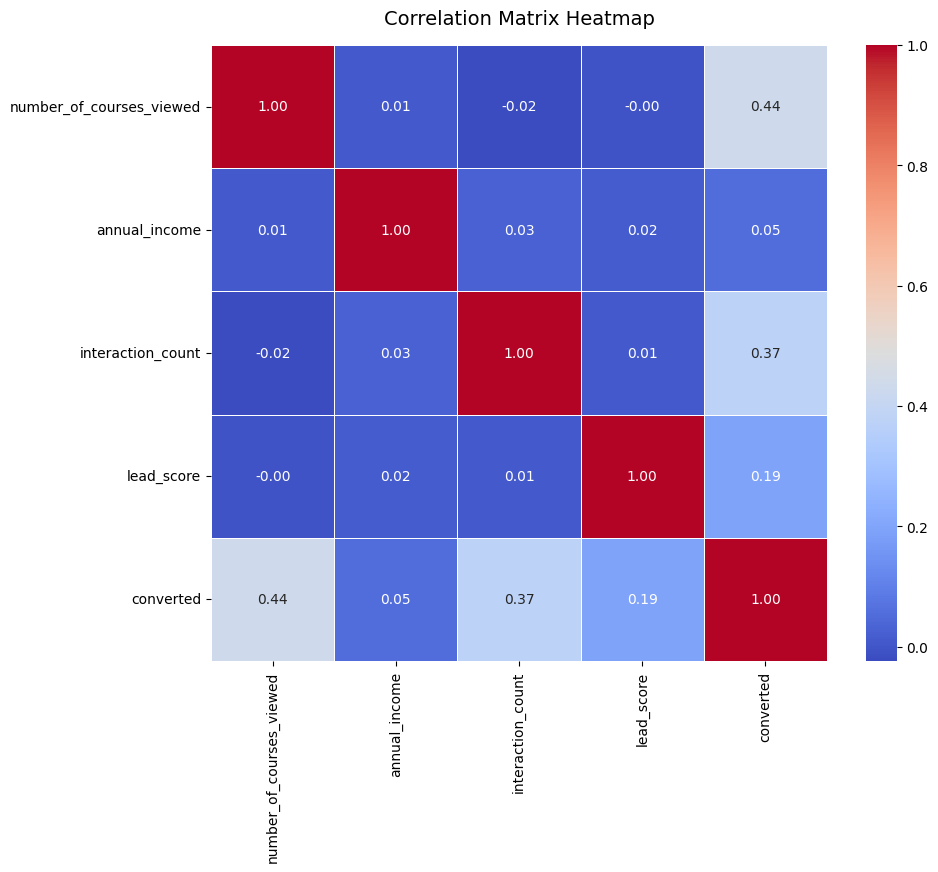

In [10]:
correlation_matrix = numerical_vars.corr()

corr_pairs = (
    correlation_matrix
    .unstack()
    .sort_values(ascending=False)
)

# --- Plot the heatmap ---
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, 
            annot=True, 
            cmap='coolwarm', 
            fmt=".2f", 
            linewidths=0.5, 
            square=True)

plt.title('Correlation Matrix Heatmap', fontsize=14, pad=15)
plt.show()

**Split the data**
- Split your data in train/val/test sets with 60%/20%/20% distribution.
- Use Scikit-Learn for that (the train_test_split function) and set the seed to 42.
- Make sure that the target value y is not in your dataframe.

In [11]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=42)

In [12]:
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=42)

In [13]:
len(df_train), len(df_val), len(df_test)

(876, 293, 293)

In [14]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [15]:
y_train = df_train.converted.values
y_val = df_val.converted.values
y_test = df_test.converted.values


del df_train['converted']
del df_val['converted']
del df_test['converted']

**Question 3. Biggest MI**
- Calculate the mutual information score between y and other categorical variables in the dataset. Use the training set only.
- Round the scores to 2 decimals using round(score, 2).
  
Which of these variables has the biggest mutual information score?

- industry
- location
- lead_source
- employment_status

**ans:** lead_source

In [16]:
categorical_vars = df_train.select_dtypes(['object'])
categorical_vars.columns

Index(['lead_source', 'industry', 'employment_status', 'location'], dtype='object')

In [17]:
def mutual_info_converted_score(series):
    return mutual_info_score(series, y_train)

mi = categorical_vars.apply(mutual_info_converted_score)
round(mi.sort_values(ascending=False),2)

lead_source          0.04
employment_status    0.01
industry             0.01
location             0.00
dtype: float64

**Question 4. Accuracy**
- Now let's train a logistic regression.
- Remember that we have several categorical variables in the dataset. Include them using one-hot encoding.
- Fit the model on the training dataset.
- To make sure the results are reproducible across different versions of Scikit-Learn, fit the model with these parameters:
    - *model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000, random_state=42)*
- Calculate the accuracy on the validation dataset and round it to 2 decimal digits.

What accuracy did you get?

- 0.64
- 0.74
- 0.84
- 0.94

In [18]:
dv = DictVectorizer(sparse=False)

In [19]:
train_dicts = df_train.to_dict(orient='records')
X_train = dv.fit_transform(train_dicts)

val_dicts = df_val.to_dict(orient='records')
X_val = dv.transform(val_dicts)

In [20]:
dv.get_feature_names_out()

array(['annual_income', 'employment_status=NA',
       'employment_status=employed', 'employment_status=self_employed',
       'employment_status=student', 'employment_status=unemployed',
       'industry=NA', 'industry=education', 'industry=finance',
       'industry=healthcare', 'industry=manufacturing', 'industry=other',
       'industry=retail', 'industry=technology', 'interaction_count',
       'lead_score', 'lead_source=NA', 'lead_source=events',
       'lead_source=organic_search', 'lead_source=paid_ads',
       'lead_source=referral', 'lead_source=social_media', 'location=NA',
       'location=africa', 'location=asia', 'location=australia',
       'location=europe', 'location=middle_east',
       'location=north_america', 'location=south_america',
       'number_of_courses_viewed'], dtype=object)

In [21]:
model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000, random_state=42) 
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'liblinear'
,max_iter,1000
,multi_class,'deprecated'


In [22]:
y_pred = model.predict_proba(X_val)[:,1]
converted_decision = (y_pred >= 0.5)

In [23]:
original_accuracy = (y_val == converted_decision).mean()
original_accuracy.round(2)

np.float64(0.7)

**Question 5. Feature selection**
- Let's find the least useful feature using the feature elimination technique.
- Train a model using the same features and parameters as in Q4 (without rounding).
- Now exclude each feature from this set and train a model without it. Record the accuracy for each model.
- For each feature, calculate the difference between the original accuracy and the accuracy without the feature.

Which of following feature has the smallest difference?

- 'industry'
- 'employment_status'
- 'lead_score'
  
Note: The difference doesn't have to be positive.

**ans:** industry

In [24]:
numerical_features = numerical_vars.columns.to_list()
categorical_features = categorical_vars.columns.to_list()
target_feature = 'converted'

all_features = numerical_features + categorical_features
all_features.remove(target_feature)

In [25]:
feature_accuracy = dict()

for feature in all_features:
    features_to_test = [f for f in all_features if f != feature ]

    dv = DictVectorizer(sparse=False)
    
    X_train = dv.fit_transform(df_train[features_to_test].to_dict(orient='records'))
    X_val = dv.transform(df_val[features_to_test].to_dict(orient='records'))
    
    model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000, random_state=42)
    model.fit(X_train, y_train)
    
    predict_y = model.predict_proba(X_val)[:,1]
    converted_decision = (predict_y >= 0.5)
    accuracy = (converted_decision == y_val).mean()

    feature_accuracy[feature] = abs(original_accuracy - accuracy)
    # print(feature, accuracy, abs(original_accuracy - accuracy))
    

In [26]:
feature_accuracy

{'number_of_courses_viewed': np.float64(0.14334470989761094),
 'annual_income': np.float64(0.15358361774744034),
 'interaction_count': np.float64(0.14334470989761094),
 'lead_score': np.float64(0.0068259385665528916),
 'lead_source': np.float64(0.0034129692832765013),
 'industry': np.float64(0.0),
 'employment_status': np.float64(0.0034129692832763903),
 'location': np.float64(0.010238907849829393)}

In [27]:
sorted(feature_accuracy, key=feature_accuracy.get)

['industry',
 'employment_status',
 'lead_source',
 'lead_score',
 'location',
 'number_of_courses_viewed',
 'interaction_count',
 'annual_income']

**Question 6. Parameter tuning**
- Now let's train a regularized logistic regression.
- Let's try the following values of the parameter C: [0.01, 0.1, 1, 10, 100].
- Train models using all the features as in Q4.
- Calculate the accuracy on the validation dataset and round it to 3 decimal digits.

Which of these C leads to the best accuracy on the validation set?

- 0.01
- 0.1
- 1
- 10
- 100

In [28]:
accuracies = {}

dv = DictVectorizer(sparse=False)

X_train = dv.fit_transform(df_train[all_features].to_dict(orient='records'))
X_val = dv.transform(df_val[all_features].to_dict(orient='records'))

for c in [0.01, 0.1, 1, 10, 100]:
    model = LogisticRegression(solver='liblinear', C=c, max_iter=1000, random_state=42) 
    model.fit(X_train, y_train)

    y_pred = model.predict_proba(X_val)[:,1]

    accuracy = (y_val == (y_pred >= 0.5)).mean()
    accuracies[c] = accuracy
    print(f'{c}: {accuracy}')
    

0.01: 0.6996587030716723
0.1: 0.6996587030716723
1: 0.6996587030716723
10: 0.6996587030716723
100: 0.6996587030716723
